In [1]:
# Feedforward block

# Clear from memory
#del model
#del optimizer
#del checkpoint
import torch
torch.cuda.empty_cache()

# Clear from disk
import os
#os.remove("checkpoint.pth")
#------------------------------------------------------------------------------------------#

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.SiLU()  # Swish

    def forward(self, x):
        # LayerNorm
        x_norm = self.norm(x)

        # Feedforward
        x_ff = self.fc1(x_norm)
        x_ff = self.activation(x_ff)
        x_ff = self.dropout(x_ff)
        x_ff = self.fc2(x_ff)

        # Residual connection
        rF = x + self.dropout(x_ff)
        return rF

In [2]:
# Covolution block

class ConformerConvModule(nn.Module):
    def __init__(self, d_model, kernel_size=31, dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(d_model)

        # Pointwise conv expands channels (2x for GLU)
        self.pointwise_conv1 = nn.Conv1d(d_model, 2 * d_model, kernel_size=1)

        # Depthwise conv
        self.depthwise_conv = nn.Conv1d(
            d_model, d_model, kernel_size=kernel_size,
            padding=kernel_size // 2, groups=d_model
        )

        self.batch_norm = nn.BatchNorm1d(d_model)
        self.activation = nn.SiLU()  # Swish

        # Pointwise conv projects back
        self.pointwise_conv2 = nn.Conv1d(d_model, d_model, kernel_size=1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        xp = self.layer_norm(x)

        # Change to (batch, channels, seq_len) for Conv1d
        xp = xp.transpose(1, 2)

        # First pointwise conv + GLU
        xp = self.pointwise_conv1(xp)
        xp, gate = xp.chunk(2, dim=1)  # split channels
        xp = xp * torch.sigmoid(gate)  # GLU

        # Depthwise conv
        xp = self.depthwise_conv(xp)
        xp = self.batch_norm(xp)
        xp = self.activation(xp)

        # Second pointwise conv
        xp = self.pointwise_conv2(xp)

        # Back to (batch, seq_len, d_model)
        xp = xp.transpose(1, 2)

        rF = x + self.dropout(xp)
        return rF

In [18]:
print(padded_units_EN.shape, padded_units_YOR.shape)

torch.Size([32, 600, 512]) torch.Size([32, 600])


In [3]:
# Positional encoding

class RelativePositionEncoding(nn.Module):
    def __init__(self, num_heads, max_len=10000):
        super().__init__()
        self.num_heads = num_heads
        self.max_len = max_len
        # Learnable bias for each relative distance per head
        self.relative_bias = nn.Embedding(2 * max_len - 1, num_heads)

    def forward(self, q_len, k_len, device=None):
        if device is None:
            device = self.relative_bias.weight.device
        pos = torch.arange(k_len, device=device)[None, :] - torch.arange(q_len, device=device)[:, None]
        pos = pos + self.max_len - 1
        bias = self.relative_bias(pos)  # (q_len, k_len, num_heads)
        return bias.permute(2, 0, 1)    # (num_heads, q_len, k_len)

In [4]:
# Multihead Attention. Function as both self-attention, and cross-attention

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1, use_positional_encoding=True, max_len=10000):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.use_positional_encoding = use_positional_encoding

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        # Positional encoding module
        if self.use_positional_encoding:
            # ✅ FIX: use num_heads, not d_model
            self.pos_enc = RelativePositionEncoding(num_heads, max_len)

    def forward(self, query, key, value, mask=None):
        batch_size, tgt_len, _ = query.size()
        src_len = key.size(1)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # Reshape for multi-head
        Q = Q.view(batch_size, tgt_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, src_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, src_len, self.num_heads, self.d_k).transpose(1, 2)

        # Attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        # Add positional encoding if enabled
        if self.use_positional_encoding:
            pos_bias = self.pos_enc(tgt_len, src_len, device=query.device)  # (num_heads, q_len, k_len)
            pos_bias = pos_bias.unsqueeze(0).expand(batch_size, -1, -1, -1) # (batch, num_heads, q_len, k_len)
            attn_scores = attn_scores + pos_bias

        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Weighted sum
        attn_output = torch.matmul(attn_weights, V)

        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, tgt_len, self.d_model)

        return self.W_o(attn_output)

In [5]:
# Conformer block

class ConformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, kernel_size=31, dropout=0.1):
        super().__init__()
        # Feedforward modules
        self.ffn1 = FeedForward(d_model, d_ff, dropout)
        self.ffn2 = FeedForward(d_model, d_ff, dropout)

        # Multi-head self-attention (with positional encoding enabled)
        self.mhsa = MultiHeadAttention(d_model, num_heads, dropout, use_positional_encoding=True)

        # Convolution module
        self.conv_module = ConformerConvModule(d_model, kernel_size, dropout)

        # Final layer norm
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # FFN1 with residual scaling
        x = x + 0.5 * self.ffn1(x)

        # MHSA with residual (positional encoding applied internally)
        x = x + self.mhsa(x, x, x, mask)

        # Convolution module with residual
        x = x + self.conv_module(x)

        # FFN2 with residual scaling
        x = x + 0.5 * self.ffn2(x)

        # Final layer norm
        return self.layer_norm(x)

In [6]:
# 1 Stack of conformer blocks - Encoder

import torch
import torch.nn as nn

class ConformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, d_ff, num_heads,
                 kernel_size=31, dropout=0.1, input_dim=None):
        super().__init__()
        # Input projection: if input_dim is given and differs from d_model
        if input_dim is not None and input_dim != d_model:
            self.input_proj = nn.Linear(input_dim, d_model)
        else:
            self.input_proj = nn.Identity()

        # Stack of Conformer blocks
        self.layers = nn.ModuleList([
            ConformerBlock(d_model, d_ff, num_heads, kernel_size, dropout)
            for _ in range(num_layers)
        ])

        # Final normalization
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Expect x shaped [batch, seq_len, input_dim]
        # Project input features if needed
        x = self.input_proj(x)   # Now [batch, seq_len, d_model]

        # Pass through stacked Conformer blocks
        for layer in self.layers:
            x = layer(x, mask)   # Each block handles MHSA + positional encoding

        # Final normalization
        return self.final_norm(x)

In [7]:
# LSTM based decoder

class LSTMDecoderBlock(nn.Module):
    def __init__(self, d_model, hidden_size, vocab_size, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)

        # Output heads
        self.phoneme_out = nn.Linear(hidden_size, vocab_size)
        self.state_proj = nn.Linear(hidden_size, d_model)

    def forward(self, x, hidden=None):
        lstm_out, hidden = self.lstm(x, hidden)  # (batch, seq_len, hidden_size)
        lstm_out = self.dropout(lstm_out)

        phoneme_logits = self.phoneme_out(lstm_out)       # supervised phoneme prediction
        projected_states = self.state_proj(lstm_out)      # for cross-attention & synthesizer

        return phoneme_logits, projected_states, hidden

In [8]:
# 2 Stack of LSTM decoder (decoder block)

class PhonemeDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, hidden_size, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)

        self.blocks = nn.ModuleList([
            LSTMDecoderBlock(d_model, hidden_size, vocab_size, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, tgt_seq, hidden=None):
        # ✅ Ensure integer IDs
        tgt_seq = tgt_seq.long()

        # Debug check
        #print(tgt_seq.min(), tgt_seq.max(), self.embedding.num_embeddings, "@")
        if (tgt_seq.min() < 0) or (tgt_seq.max() >= self.embedding.num_embeddings):
            print(tgt_seq.min(), tgt_seq.max(), self.embedding.num_embeddings, "@")
            raise ValueError(
                f"Phoneme IDs out of range: min={tgt_seq.min().item()}, "
                f"max={tgt_seq.max().item()}, vocab_size={self.embedding.num_embeddings}"
            )
            
        x = self.embedding(tgt_seq)  # (batch, seq_len, d_model)

        phoneme_logits_list = []
        projected_states_list = []

        for block in self.blocks:
            phoneme_logits, projected_states, hidden = block(x, hidden)
            phoneme_logits_list.append(phoneme_logits)
            projected_states_list.append(projected_states)
            x = projected_states

        return phoneme_logits_list[-1], projected_states_list[-1], hidden

In [9]:
## Synthesizer

# Duration predictor
class DurationPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Predict durations per phoneme
        return self.fc2(self.relu(self.fc1(x))).squeeze(-1)  # (batch, seq_len)


# Upsampler
class Upsampler(nn.Module):
    def forward(self, z, durations):
        # z: (batch, seq_len, dim)
        # durations: (batch, seq_len)
        upsampled = []
        for b in range(z.size(0)):
            seq = []
            for t in range(z.size(1)):
                dur = max(1, int(durations[b, t].item()))
                seq.extend([z[b, t]] * dur)
            upsampled.append(torch.stack(seq))
        return nn.utils.rnn.pad_sequence(upsampled, batch_first=True)


# Synthesizer
import torch
import torch.nn as nn

class Synthesizer(nn.Module):
    def __init__(self, d_model, rnn_dim, vocab_size):
        super().__init__()
        # Projections for continuous inputs
        self.phoneme_proj = nn.Linear(d_model, d_model)
        self.encoder_proj = nn.Linear(d_model, d_model)

        # After concat(hidden, attention), dimension = 2*d_model
        concat_dim = 2 * d_model

        # Duration predictor
        self.duration_predictor = DurationPredictor(concat_dim, rnn_dim)

        # Upsampler
        self.upsampler = Upsampler()

        # RNN
        self.rnn = nn.LSTM(concat_dim, rnn_dim, batch_first=True)

        # Final classifier → discrete unit logits
        self.classifier = nn.Linear(rnn_dim, vocab_size)

    def forward(self, hidden, attention):
        # Step 1: project continuous inputs
        hidden = self.phoneme_proj(hidden)        # (batch, seq_len, d_model)
        attention = self.encoder_proj(attention)  # (batch, seq_len, d_model)

        # Step 2: concat hidden + attention
        z = torch.cat([hidden, attention], dim=-1)   # (batch, seq_len, 2*d_model)

        # Step 3: predict durations
        durations = self.duration_predictor(z)       # (batch, seq_len)

        # Step 4: upsample using (z, durations)
        upsampled = self.upsampler(z, durations)     # (batch, frame_len, 2*d_model)

        # Step 5: RNN
        rnn_out, _ = self.rnn(upsampled)             # (batch, frame_len, rnn_dim)

        # Step 6: Linear → logits over target units
        logits = self.classifier(rnn_out)            # (batch, frame_len, vocab_size)

        print(logits.shape)
        return logits

In [10]:
# Extract discrete units for ENGLISH and YORUBA
import os
import glob
import torch
import torchaudio
import numpy as np
import warnings
from transformers import HubertModel, Wav2Vec2FeatureExtractor
import joblib

# Suppress TorchCodec warnings
warnings.filterwarnings("ignore", message=".*TorchCodec.*")

# 1. Load pretrained HuBERT
#hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960").to("cuda")
#feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

model_path = "/home/gabriel/.cache/huggingface/hub/models--facebook--hubert-base-ls960/snapshots/dba3bb02fda4248b6e082697eee756de8fe8aa8a"
hubert = HubertModel.from_pretrained(model_path, local_files_only = True).to("cuda")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_path, local_files_only = True)

# 2. Load pretrained k-means (joblib pickle)
kmeans = joblib.load("hubert_base_ls960_L9_km500.bin")

# 3. Function to extract discrete units
def extract_units(wav_path):
    # Force sox_io backend to avoid TorchCodec warnings
    waveform, sr = torchaudio.load(wav_path, backend="sox_io")
    waveform = torchaudio.functional.resample(waveform, sr, 16000)

    arr = waveform.squeeze().numpy()
    inputs = feature_extractor(arr, sampling_rate=16000, return_tensors="pt")

    with torch.inference_mode():
        outputs = hubert(**inputs.to("cuda"))
    features = outputs.last_hidden_state.cpu().numpy()

    features_2d = features.reshape(-1, features.shape[-1])
    units = kmeans.predict(features_2d)
    return units

# 4. Batch process all audios
input_folder_EN = "/home/gabriel/s2st_project/ENGLISH"
input_folder_YOR = "/home/gabriel/s2st_project/YORUBA"

files_EN = glob.glob(os.path.join(input_folder_EN, "*.wav"))
files_YOR = glob.glob(os.path.join(input_folder_YOR, "*.wav"))
print(f"Found {len(files_EN)} ENGLISH wav files"); print(f"Found {len(files_YOR)} YORUBA wav files"); 

all_units_EN = []
for wav_path in files_EN:
    units_EN = extract_units(wav_path)
    all_units_EN.append(units_EN)

all_units_YOR = []
for wav_pt in files_YOR:
    units_YOR = extract_units(wav_pt)
    all_units_YOR.append(units_YOR)

/home/gabriel/s2st_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 38625.97it/s]
/home/gabriel/s2st_env/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MiniBatchKMeans from version 0.24.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Found 32 ENGLISH wav files
Found 32 YORUBA wav files


In [11]:
# 5. Pad sequences to same length
max_len_EN = max(len(u) for u in all_units_EN)
max_len_YOR = max(len(u) for u in all_units_YOR); 
print(max_len_YOR, max_len_EN)
max_val = max(max_len_EN, max_len_YOR); print(max_val)

padded_units_EN = np.full((len(all_units_EN), max_val), fill_value=0, dtype=np.int32)
for i, u in enumerate(all_units_EN):
    padded_units_EN[i, :len(u)] = u
padded_units_EN = padded_units_EN[:, :600]
print(padded_units_EN.shape)

padded_units_YOR = np.full((len(all_units_YOR), max_val), fill_value=0, dtype=np.int32)
for m, k in enumerate(all_units_YOR):
    padded_units_YOR[m, :len(k)] = k
padded_units_YOR = padded_units_YOR[:, :600]
print(padded_units_YOR.shape)


1040 712
1040
(32, 600)
(32, 600)


In [12]:
# Batch process all audios
from torch.utils.data import DataLoader, TensorDataset

padded_units_EN = torch.tensor(padded_units_EN)
padded_units_YOR = torch.tensor(padded_units_YOR)

print(padded_units_EN.shape)
print(padded_units_YOR.shape)

torch.Size([32, 600])
torch.Size([32, 600])


In [13]:
import torch
import torch.nn as nn

hubert_vocab = 500   # number of clusters
embed_dim = 512

# set padding_idx to the value you used for padding (-1 won't work, so remap it to 0)
hubert_embed = nn.Embedding(hubert_vocab, embed_dim, padding_idx=0)

# replace -1 with 0 in your padded units before embedding
padded_units_EN = torch.tensor(padded_units_EN, dtype=torch.long)
padded_units_EN[padded_units_EN == -1] = 0

# now embed
padded_units_EN = hubert_embed(padded_units_EN)

print(padded_units_EN.shape)   # should be [200, max_len, 512]


torch.Size([32, 600, 512])


/tmp/ipykernel_7170/3476692247.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_units_EN = torch.tensor(padded_units_EN, dtype=torch.long)


In [14]:
print(padded_units_EN.shape)   # should be [200, max_len, 512]
print(padded_units_YOR.shape)
print(padded_units_EN[0])

torch.Size([32, 600, 512])
torch.Size([32, 600])
tensor([[ 0.8741,  0.1846,  1.3827,  ..., -0.7297,  2.1715,  0.2247],
        [ 0.8741,  0.1846,  1.3827,  ..., -0.7297,  2.1715,  0.2247],
        [ 0.8741,  0.1846,  1.3827,  ..., -0.7297,  2.1715,  0.2247],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       grad_fn=<SelectBackward0>)


In [15]:
################################################################################################
################################################################################################
#################################  A SINGLE TRAINING LOOP FOR ALL    ###########################
################################################################################################
################################################################################################

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# -------------------------------
# Example dataset
# -------------------------------
class SpeechPhonemeDataset(Dataset):
    def __init__(self, src_feats, tgt_phonemes):
        self.src_feats = src_feats
        self.tgt_phonemes = tgt_phonemes

    def __len__(self):
        return len(self.src_feats)

    def __getitem__(self, idx):
        return self.src_feats[idx], self.tgt_phonemes[idx]



# -------------------------------
# Model wrapper with Synthesizer
# -------------------------------
class S2STModel(nn.Module):
    def __init__(self, encoder, phoneme_decoder, cross_attention, synthesizer):
        super().__init__()
        self.encoder = encoder
        self.phoneme_decoder = phoneme_decoder
        self.cross_attention = cross_attention
        self.synthesizer = synthesizer

    def forward(self, src_feats, tgt_phonemes, mask=None):
        """
        Training forward pass: requires both source features and target phonemes.
        """
        enc_out = self.encoder(src_feats, mask)
        phoneme_logits, hidden_states, _ = self.phoneme_decoder(tgt_phonemes)
        attn_out = self.cross_attention(hidden_states, enc_out, enc_out, mask)
        unit_logits = self.synthesizer(hidden_states, attn_out)
        return phoneme_logits, unit_logits

    def infer(self, src_feats, mask=None):
        """
        Inference forward pass: only source features, no target phonemes.
        """
        enc_out = self.encoder(src_feats, mask)

        # Simplest option: use encoder outputs as hidden states
        hidden_states = enc_out

        attn_out = self.cross_attention(hidden_states, enc_out, enc_out, mask)
        unit_logits = self.synthesizer(hidden_states, attn_out)

        # Argmax → discrete unit IDs
        predicted_units = torch.argmax(unit_logits, dim=-1)
        return predicted_units


# -------------------------------
# Training loop
# -------------------------------
def train(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for src_feats, tgt_phonemes in dataloader:
        src_feats = src_feats.to(device)
        tgt_phonemes = tgt_phonemes.to(device)

        optimizer.zero_grad()

        phoneme_logits, unit_logits = model(src_feats, tgt_phonemes)

        # Loss: discrete unit prediction
        loss = loss_fn(
            unit_logits.view(-1, unit_logits.size(-1)),
            tgt_phonemes.view(-1)
        )

        loss.backward(retain_graph=True)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

# save checkpoint file
def save_checkpoint(model, optimizer, epoch, loss, path="checkpoints"):
    os.makedirs(path, exist_ok=True)
    checkpoint_path = os.path.join(path, f"epoch_{epoch}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")



# -------------------------------
# Example usage
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = ConformerEncoder(
    num_layers=6,
    d_model=512,
    d_ff=1024,
    num_heads=4,
    kernel_size=31,
    dropout=0.1,
    input_dim=512
)

phoneme_decoder = PhonemeDecoder(
    vocab_size=500,
    d_model=512,
    hidden_size=512,
    num_layers=2,
    dropout=0.1
)

cross_attention = MultiHeadAttention(
    d_model=512,
    num_heads=4,
    dropout=0.1,
    use_positional_encoding=False
)

synthesizer = Synthesizer(
    d_model=512,
    rnn_dim=512,
    vocab_size=500   # Yoruba unit vocabulary size
)

model = S2STModel(
    encoder=encoder,
    phoneme_decoder=phoneme_decoder,
    cross_attention=cross_attention,
    synthesizer=synthesizer
).to(device)


pad_token = 0;
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token)  # pad_token = e.g. 499 or 500

dataset = SpeechPhonemeDataset(padded_units_EN, padded_units_YOR.long())
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [16]:
num_epochs = 3; lsc = []
for epoch in range(num_epochs):
    avg_loss = train(model, train_loader, optimizer, loss_fn, device)
    lsc.append(avg_loss)
    print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")
    # Save checkpoint automatically at the end of each epoch
    save_checkpoint(model, optimizer, epoch, avg_loss)

torch.Size([16, 600, 500])
torch.Size([16, 600, 500])
Epoch 0: Loss = 6.2081
Checkpoint saved: checkpoints/epoch_0.pt
torch.Size([16, 600, 500])
torch.Size([16, 600, 500])
Epoch 1: Loss = 6.1696
Checkpoint saved: checkpoints/epoch_1.pt
torch.Size([16, 600, 500])


KeyboardInterrupt: 

In [20]:
# checking the contents of a saved checkpoint file
import torch

# Load the checkpoint
checkpoint = torch.load("checkpoints/epoch_2.pt", map_location="cpu")

# See the keys
print("Checkpoint keys:", checkpoint.keys())

# For example, you might see:
# dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])

# Inspect the epoch and loss
print("Epoch:", checkpoint['epoch'])
print("Loss:", checkpoint['loss'])

# Inspect the model weights
model_state = checkpoint['model_state_dict']
print("Number of parameters saved:", len(model_state))

# Print a few parameter names and shapes
for name, param in list(model_state.items())[:5]:
    print(name, param.shape)

Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])
Epoch: 2
Loss: 6.116892099380493
Number of parameters saved: 257
encoder.layers.0.ffn1.norm.weight torch.Size([512])
encoder.layers.0.ffn1.norm.bias torch.Size([512])
encoder.layers.0.ffn1.fc1.weight torch.Size([1024, 512])
encoder.layers.0.ffn1.fc1.bias torch.Size([1024])
encoder.layers.0.ffn1.fc2.weight torch.Size([512, 1024])


In [16]:
checkpoint = torch.load("checkpoints/epoch_1.pt", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch']
best_loss = checkpoint['loss']
print(f"Resumed from epoch {start_epoch}, loss {best_loss:.4f}")

Resumed from epoch 1, loss 6.1696


In [18]:
for epoch in range(start_epoch+1, 3):
    avg_loss = train(model, train_loader, optimizer, loss_fn, device)
    save_checkpoint(model, optimizer, epoch, avg_loss)

torch.Size([16, 600, 500])
torch.Size([16, 600, 500])
Checkpoint saved: checkpoints/epoch_2.pt


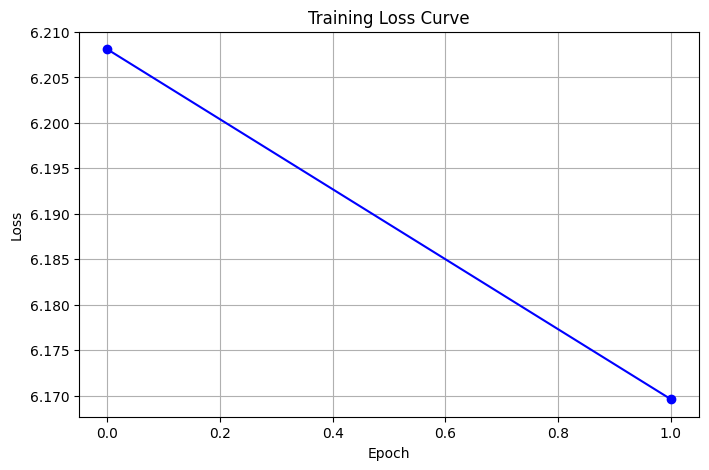

In [22]:
import matplotlib.pyplot as plt

# Example loss values from your training loop
#losses = lsc
losses = [6.2081, 6.1696]
#losses = [6.2129, 6.1824, 6.1279, 6.0468, 5.9492, 5.8500, 5.7605, 5.6781, 5.6148, 5.5501, 5.4937, 5.4410, 5.3950, 5.3509, 5.3175, 5.2858, 5.2542,
          #5.2236, 5.1941, 5.1665]

epochs = range(len(losses))

plt.figure(figsize=(8,5))
plt.plot(epochs, losses, marker='o', linestyle='-', color='blue')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [23]:
# Extract discrete units for ENGLISH and YORUBA for evaluation
import os
import glob
import torch
import torchaudio
import numpy as np
import warnings
from transformers import HubertModel, Wav2Vec2FeatureExtractor
import joblib

# Suppress TorchCodec warnings
warnings.filterwarnings("ignore", message=".*TorchCodec.*")

# 4. Batch process all audios
in_EN = "/home/gabriel/s2st_project/ENG_EVAL"
in_YOR = "/home/gabriel/s2st_project/YOR_EVAL"

f_EN = glob.glob(os.path.join(in_EN, "*.wav"))
f_YOR = glob.glob(os.path.join(in_YOR, "*.wav"))
print(f"Found {len(f_EN)} ENGLISH wav files"); print(f"Found {len(f_YOR)} YORUBA wav files"); 

eval_EN = []
for wavs in f_EN:
    u_EN = extract_units(wavs)
    eval_EN.append(u_EN)

eval_YOR = []
for wavs in f_YOR:
    u_YOR = extract_units(wavs)
    eval_YOR.append(u_YOR)

Found 16 ENGLISH wav files
Found 16 YORUBA wav files


In [24]:
# 5. Pad sequences to same length
mx_len_EN = max(len(u) for u in eval_EN)
mx_len_YOR = max(len(u) for u in eval_YOR); 
print(mx_len_YOR, mx_len_EN)
mx_val = max(mx_len_EN, mx_len_YOR); print(mx_val)

padded_eval_EN = np.full((len(eval_EN), mx_val), fill_value=0, dtype=np.int32)
for i, u in enumerate(eval_EN):
    padded_eval_EN[i, :len(u)] = u
padded_eval_EN = padded_eval_EN[:, :600]
print(padded_eval_EN.shape)

padded_eval_YOR = np.full((len(eval_YOR), mx_val), fill_value=0, dtype=np.int32)
for m, k in enumerate(eval_YOR):
    padded_eval_YOR[m, :len(k)] = k
padded_eval_YOR = padded_eval_YOR[:, :600]
print(padded_eval_YOR.shape)


806 605
806
(16, 600)
(16, 600)


In [25]:
import torch
import torch.nn as nn

hubert_vocab = 500   # number of clusters
embed_dim = 512

# set padding_idx to the value you used for padding (-1 won't work, so remap it to 0)
hubert_embed = nn.Embedding(hubert_vocab, embed_dim, padding_idx=0)

# replace -1 with 0 in your padded units before embedding
padded_eval_EN = torch.tensor(padded_eval_EN, dtype=torch.long)
padded_eval_EN[padded_eval_EN == -1] = 0

# now embed
padded_eval_EN = hubert_embed(padded_eval_EN)

print(padded_eval_EN.shape)   # should be [200, max_len, 512]
print(padded_eval_YOR.shape)

torch.Size([16, 600, 512])
(16, 600)


In [26]:

padded_eval_EN = torch.tensor(padded_eval_EN)
padded_eval_YOR = torch.tensor(padded_eval_YOR)

print(padded_eval_EN.shape)
print(padded_eval_YOR.shape)

torch.Size([16, 600, 512])
torch.Size([16, 600])


/tmp/ipykernel_7170/4235616805.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_eval_EN = torch.tensor(padded_eval_EN)


torch.Size([16, 600, 500])


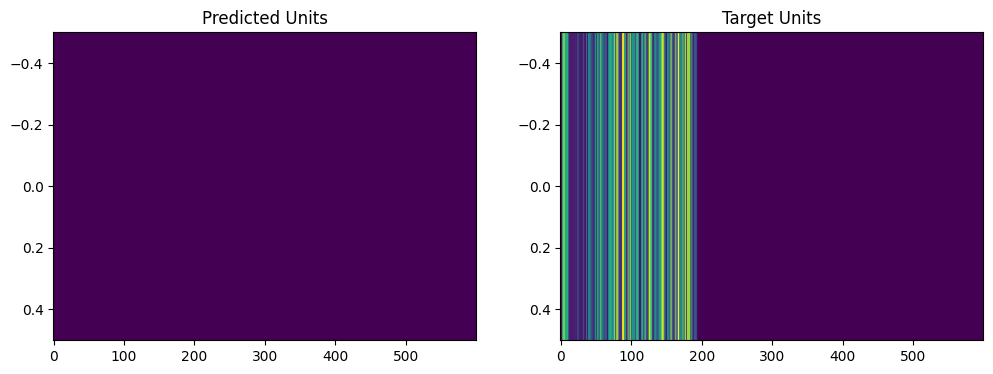

Validation Loss: 6.1166
Accuracy: 0.0049
[tensor([[249, 249, 249,  ..., 249, 249, 249],
        [249, 249, 249,  ..., 249, 249, 249],
        [249, 249, 249,  ..., 249, 249, 249],
        ...,
        [249, 249, 249,  ..., 249, 249, 249],
        [249, 249, 249,  ..., 249, 249, 249],
        [249, 249, 249,  ..., 249, 249, 249]])]


In [27]:
################################################################################################
################################################################################################
#################################  A SINGLE EVALUATION LOOP FOR ALL    ###########################
################################################################################################
################################################################################################


import torch
import matplotlib.pyplot as plt

# -------------------------------
# Example dataset
# -------------------------------
class SpeechPhonemeDataset(Dataset):
    def __init__(self, src_feats, tgt_phonemes):
        self.src_feats = src_feats
        self.tgt_phonemes = tgt_phonemes

    def __len__(self):
        return len(self.src_feats)

    def __getitem__(self, idx):
        return self.src_feats[idx], self.tgt_phonemes[idx]

def evaluate(model, dataloader, loss_fn, device, visualize=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    all_preds = []

    with torch.no_grad():
        for src_feats, tgt_phonemes in dataloader:
            src_feats = src_feats.to(device)
            tgt_phonemes = tgt_phonemes.to(device)

            # Forward pass
            _, unit_logits = model(src_feats, tgt_phonemes)

            # Loss
            loss = loss_fn(
                unit_logits.view(-1, unit_logits.size(-1)),
                tgt_phonemes.view(-1)
            )
            total_loss += loss.item()

            # Predictions
            preds = unit_logits.argmax(dim=-1).cpu()
            all_preds.append(preds)

            # Accuracy (ignore pad=0)
            targets = tgt_phonemes.cpu()
            mask = (targets != 0)
            correct = (preds[mask] == targets[mask]).sum().item()
            total = mask.sum().item()
            total_correct += correct
            total_tokens += total

            # Optional visualization: plot predicted vs target units
            if visualize:
                plt.figure(figsize=(12,4))
                plt.subplot(1,2,1)
                plt.title("Predicted Units")
                plt.imshow(preds[0].unsqueeze(0), aspect='auto', cmap="viridis")
                plt.subplot(1,2,2)
                plt.title("Target Units")
                plt.imshow(targets[0].unsqueeze(0), aspect='auto', cmap="viridis")
                plt.show()

    avg_loss = total_loss / len(dataloader)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, accuracy, all_preds

val_src = padded_eval_EN; # shape: [batch_size, seq_len, d_model]
val_tgt_phonemes = padded_eval_YOR; # shape: [batch_size, seq_len, d_model]

datas = SpeechPhonemeDataset(val_src, val_tgt_phonemes.long())
val_loader = DataLoader(datas, batch_size=16, shuffle=True)

# Call the evaluation function
avg_loss, accuracy, preds = evaluate(model, val_loader, loss_fn, device, visualize=True)

print(f"Validation Loss: {avg_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(preds)

In [28]:
print(preds[0].shape)
print(preds[0][0].shape)
print(preds[0][1])

torch.Size([16, 600])
torch.Size([600])
tensor([249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
        249, 249, 249, 2

In [30]:
# Evaluate the first audio predicted if it corresponds to the original audio at index 0 ---> print(preds[0][0])
yp = preds[0][0]

import os
import sys

# 1. Set working directory so Python can see hifi-gan modules
#os.chdir("/home/gabriel/hifi_discrete_proj")
sys.path.append("/home/gabriel/hifi_discrete_proj/unit-hifigan/src")

import torch
from unit_hifigan import UnitVocoder
#from model import UnitVocoder
import soundfile as sf

# Load the finetuned vocoder
#vocoder = UnitVocoder.from_pretrained("runs_hubert/yoruba_vocoder/vocoder-50000")
vocoder = UnitVocoder.from_pretrained("runs_hubert/yoruba_vocoder/vocoder-50000", local_files_only=True)

units_list = yp

# Convert to tensor with batch dimension
units = torch.tensor(units_list).unsqueeze(0)

# Generate audio
audio = vocoder.generate(units)

os.chdir("/home/gabriel/s2st_project")
# Save to WAV
sf.write("generated_s2st_eval.wav", audio.squeeze().cpu().numpy(), 16000)

Loading weights from local directory


/tmp/ipykernel_7170/2715717907.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  units = torch.tensor(units_list).unsqueeze(0)


In [31]:
# train data
print(padded_units_EN.shape)   # should be [200, seq_len, 512]
print(padded_units_YOR.shape)

# eval data
print(padded_eval_EN.shape)
print(padded_eval_YOR.shape)


print(padded_units_EN[0: 1].shape)
eng_src = padded_units_EN[0: 1]

torch.Size([32, 600, 512])
torch.Size([32, 600])
torch.Size([16, 600, 512])
torch.Size([16, 600])
torch.Size([1, 600, 512])


In [32]:
# Generate audios / inference using just the source English discrete embedded values of shape [batch_size, seq_len, d_model]


model.eval()
with torch.no_grad():
    src_feats = eng_src.to(device)  # single English input
    predicted_units = model.infer(src_feats)

"""
# Feed into vocoder
vocoder = UnitVocoder.from_pretrained("runs_wavlm/yoruba_vocoder/vocoder-50000", local_files_only=True)
audio = vocoder.generate(predicted_units)

import soundfile as sf
sf.write("generated_inference.wav", audio.squeeze().cpu().numpy(), 16000)
"""
print(predicted_units)

torch.Size([1, 600, 500])
tensor([[249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249, 249,
         249, 249, 249, 24

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import os
import sys

# 1. Set working directory so Python can see hifi-gan modules
os.chdir("/home/gabriel/hifi_discrete_proj")
#sys.path.append("/home/gabriel/hifi_discrete_proj/unit-hifigan/src")

import torch
from unit_hifigan import UnitVocoder
#from model import UnitVocoder
import soundfile as sf

# Load the finetuned vocoder
#vocoder = UnitVocoder.from_pretrained("runs_hubert/yoruba_vocoder/vocoder-50000")
vocoder = UnitVocoder.from_pretrained("runs_hubert/yoruba_vocoder/vocoder-50000", local_files_only=True).to(device)

units_list = predicted_units[0].to(device)

# Convert to tensor with batch dimension
units = torch.tensor(units_list).unsqueeze(0)

# Generate audio
audio = vocoder.generate(units).to(device)

os.chdir("/home/gabriel/s2st_project")
# Save to WAV
sf.write("generated_s2st_inf.wav", audio.squeeze().cpu().numpy(), 16000)


Loading weights from local directory


/tmp/ipykernel_7170/4122301875.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  units = torch.tensor(units_list).unsqueeze(0)
